# 1D Wang-Landau — lattice gas at fixed chemical potential

This notebook is the first, simpler stage of the project: a **1D Wang-Landau**
random walk over a single energy variable, at a **fixed chemical potential**
mu = -2*eps (the particle-hole symmetric point of the model). It served as a
warm-up and correctness check before extending the method to a joint
(E, N) random walk (see `2D_wang_landau.ipynb`), which lets mu be varied
freely in post-processing instead of being fixed from the start.

Physical background, the Ising <-> lattice gas mapping, and the Wang-Landau
algorithm are described in the top-level `README.md`.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

## Physical parameters

`eps` sets the interaction strength between occupied nearest-neighbor sites. `mu` is fixed here at the particle-hole symmetric point, -2*eps. The total energy H = -eps * (occupied bonds) - mu * N ranges over `[0, L*L]` for an LxL lattice with this parametrization, so `lng`/`H` are indexed directly by that single energy value.

In [ ]:
# ============================================================
# PHYSICAL PARAMETERS
# ============================================================

eps = 1
mu = -2 * eps          # particle-hole symmetric point
temperature = 1.0
kb = 1.0
beta = 1.0 / (temperature * kb)

L = 8
Emin = 0
Emax = L * L
E = np.arange(Emin, Emax + 1)
n_bins = len(E)

lng = np.zeros(n_bins)   # ln g(E), the running estimate of the density of states
H = np.zeros(n_bins)     # visit histogram, used for the flatness check
ln_f = 1                 # ln of the Wang-Landau modification factor

## Initial configuration

A random LxL occupation matrix (`n[i,j] in {0,1}`) is generated, and its total energy is computed directly (the "slow" way) once, as the starting point for the random walk.

In [ ]:
# ============================================================
# INITIAL CONFIGURATION
# ============================================================

def total_energy(n, L):
    """Full O(L^2) recomputation of H = -eps*(occupied bonds) - mu*N.
    Used only once, to initialize the walk (the main loop uses the
    O(1) incremental update below)."""
    bonds = np.sum(n * np.roll(n, -1, axis=1)) + np.sum(n * np.roll(n, -1, axis=0))
    N = np.sum(n)
    return -eps * bonds - mu * N

rng = np.random.default_rng(42)                 # seeded RNG, for reproducibility
n = rng.integers(0, 2, size=(L, L))              # random LxL matrix of occupation numbers
E0 = total_energy(n, L)

## Single-site flip: incremental energy difference

Flipping one site only changes the bonds touching that site, so the energy difference can be computed in O(1) instead of recomputing the whole lattice energy after every trial move. This was cross-checked against the full `total_energy` recomputation during development.

In [ ]:
# ============================================================
# INITIAL MOVE
# ============================================================

i = rng.integers(0, n.shape[0])   # pick a random site
j = rng.integers(0, n.shape[1])

def energy_difference(n, i, j, L):
    """O(1) energy change from flipping site (i, j)."""
    return (1 - 2 * n[i, j]) * (
        -eps * (n[(i + 1) % L, j] + n[(i - 1) % L, j] + n[i, (j - 1) % L] + n[i, (j + 1) % L])
        - mu
    )

deltaE = energy_difference(n, i, j, L)
Enew = E0 + deltaE
delta = lng[E0] - lng[Enew]

## Wang-Landau main loop

Standard Wang-Landau random walk:

1. Propose flipping a random site; accept with probability min(1, g(E_old)/g(E_new)), i.e. accept if `delta = lng[E_old] - lng[E_new] >= 0`, otherwise accept with probability `exp(delta)`.
2. Whether accepted or not, update `lng[E] += ln_f` and `H[E] += 1` at the (possibly unchanged) current energy.
3. Every `100*L**2` steps, check the histogram flatness: if every visited bin has at least `p` times the mean visit count, the histogram is "flat" — halve `ln_f` (halve, not take the square root, since we are working in log-space) and reset `H`.
4. Stop once `ln_f < 1e-8`.

`Hold` keeps the last histogram before it gets reset to zero, so it can be used afterwards as a record of which energies were actually visited.

In [ ]:
# ============================================================
# WANG-LANDAU MAIN LOOP
# ============================================================

Eold = E0.copy()
n_new = n.copy()
step_count = 0
p = 0.8            # flatness criterion
n_frames = []       # optional: snapshots of the lattice, for an animation

while ln_f > 1e-8:
    r = rng.uniform(0, 1)
    if delta >= 0 or r < np.exp(delta):
        n_new[i, j] = 1 - n_new[i, j]
        Eold = Enew.copy()

    lng[Eold] += ln_f
    H[Eold] += 1

    i = rng.integers(0, n.shape[0])
    j = rng.integers(0, n.shape[1])
    deltaE = energy_difference(n_new, i, j, L)
    Enew = Eold + deltaE
    delta = lng[Eold] - lng[Enew]

    step_count += 1
    if step_count % (100 * L ** 2) == 0:
        mask = H[H > 0]
        threshold = np.mean(mask) * p
        H_min = np.min(mask)
        if H_min >= threshold:
            ln_f = 0.5 * ln_f       # halve (not sqrt), since we work with logarithms
            Hold = H.copy()
            H = np.zeros(n_bins)

    if step_count % (1000 * L ** 2) == 0:
        n_frames.append(n_new.copy())

### Visit histogram at the last flatness check

Sanity check: the histogram of visited energies should look reasonably flat across the accessible range (the flatness criterion is exactly what the main loop enforces before halving `ln_f`).

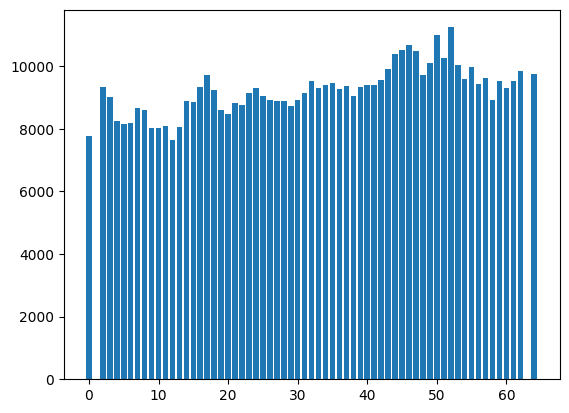

In [ ]:
plt.bar(E, Hold)
plt.xlabel('E')
plt.ylabel('visit count')
plt.show()

## Normalizing ln g(E)

Wang-Landau only determines g(E) up to an overall multiplicative constant. It is fixed using the one thing we know exactly: the total number of microstates of an LxL lattice gas is 2^(L^2), so `sum(g(E)) = 2**(L*L)`, i.e. `log-sum-exp(lng) = L**2 * log(2)`.

The two clear outliers near the edges of the plot below (very negative ln g, far below the smooth bulk of the curve) are energy bins that the random walk never actually visited (`H = 0`); they simply start at `lng = 0` and inherit the additive normalization constant, so they do **not** represent a real, well-converged estimate of g(E). They are excluded from every physical quantity below via the `Hold > 0` mask.

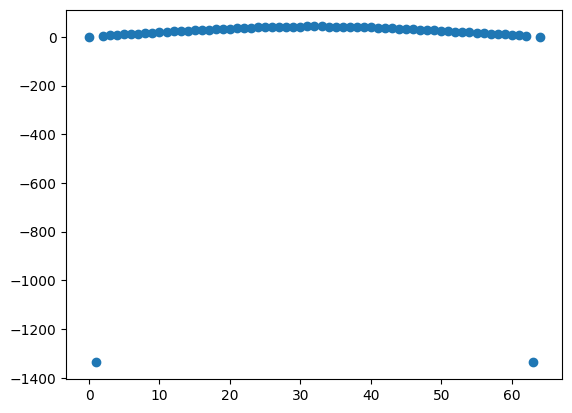

In [ ]:
# Normalization constant for ln g(E)

ln_sum_lng = np.max(lng) + np.log(np.sum(np.exp(lng - np.max(lng))))
cte = L ** 2 * np.log(2) - ln_sum_lng
lng = lng + cte

plt.scatter(E, lng)
plt.xlabel('E')
plt.ylabel('ln g(E)')
plt.show()

## Partition function Z(T) and thermodynamics

With g(E) known (up to the fixed normalization), any canonical-ensemble quantity at any temperature is a cheap weighted sum over the table — no new simulation is needed. `mask = Hold > 0` restricts every sum to the energies that were actually sampled.

In [ ]:
# Partition function Z(T)

mask = Hold > 0
Z_E = lng[mask] - beta * E[mask]
lnZ = np.max(Z_E) + np.log(np.sum(np.exp(Z_E - np.max(Z_E))))
print(f"ln Z = {lnZ}")

ln Z = 16.60222539426931

### Specific heat Cv(T)

`<E>(T)` is computed for a range of temperatures using the weighted-average trick (subtracting the maximum exponent before exponentiating, to avoid overflow), and Cv(T) = d<E>/dT is obtained with a numerical derivative. The peak locates the critical temperature; for L=8 this gives Tc ~ 0.589, compared to the exact Onsager value Tc/eps = 2/(4*ln(1+sqrt(2))) ~ 0.567 — the ~4% deviation is the finite-size effect expected for this lattice size.

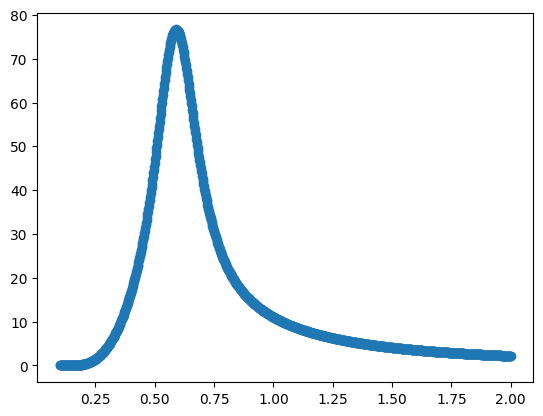

Tc = 0.5887887887887888

In [ ]:
# Specific heat Cv(T)

T = np.linspace(0.1, 2, 1000)
meanE = []
for t in T:
    exponent = lng[mask] - E[mask] / t
    w = np.exp(exponent - np.max(exponent))   # each weight w in [0, 1]: Boltzmann weight of that energy
    meanE.append(np.sum(E[mask] * w) / np.sum(w))

meanE = np.array(meanE)
Cv = np.gradient(meanE, T)

plt.scatter(T, Cv)
plt.xlabel('T')
plt.ylabel('Cv')
plt.show()

Tc = T[np.argmax(Cv)]
print(f"Tc = {Tc}")